# Хи-квадрат и критерий Колмогорова–Смирнова

Задача: оценить влияние внедрения ERP на доход пяти подразделений.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

a = np.array([120, 165, 140, 150, 130])
b = np.array([145, 155, 140, 160, 150])

df = pd.DataFrame({"Месяц": range(1, 6), "До_ERP": a, "После_ERP": b})
df


,Месяц,До_ERP,После_ERP
0,1,120,145
1,2,165,155
2,3,140,140
3,4,150,160
4,5,130,150


## 1. Критерий хи-квадрат

H0: доход до и после внедрения независим от периода. H1: зависимость есть. Строка и столбец «Всего» в расчёт не входят.

In [3]:
observed = np.vstack([a, b])

chi2, p, dof, expected = stats.chi2_contingency(observed)
print(f"Хи-квадрат = {chi2:.4f}")
print(f"Степени свободы = {dof}")
print(f"p-value = {p:.4f}")
print()
print("Таблица ожидаемых величин:")
print(pd.DataFrame(expected.round(2), index=["до", "после"], columns=["1", "2", "3", "4", "5"]))
print()
if p < 0.05:
    print("p < 0.05. H0 отвергается. Доход изменился после внедрения.")
else:
    print("p >= 0.05. H0 не отвергается. Значимой связи не выявлено.")

Хи-квадрат = 3.0333
Степени свободы = 4
p-value = 0.5523

Таблица ожидаемых величин:
           1       2       3       4       5
до     128.4  155.05  135.67  150.21  135.67
после  136.6  164.95  144.33  159.79  144.33

p >= 0.05. H0 не отвергается. Значимой связи не выявлено.


## 2. Критерий Колмогорова–Смирнова

Проверка: вырос ли доход после внедрения ERP. H0: распределения дохода до и после одинаковы. H1: распределение после сдвинуто в сторону роста.

In [4]:
D, p = stats.ks_2samp(b, a)
print(f"Средний доход до: {a.mean():.2f}")
print(f"Средний доход после: {b.mean():.2f}")
print(f"Разница средних: {b.mean() - a.mean():.2f}")
print()
print(f"Статистика D = {D:.4f}")
print(f"p-value = {p:.4f}")
print()
if b.mean() > a.mean() and p < 0.05:
    print("Сдвиг вверх значим. Прибыль увеличилась.")
elif b.mean() > a.mean():
    print("Средняя прибыль выросла, но сдвиг статистически не значим.")
else:
    print("Рост прибыли не подтверждён.")

Средний доход до: 141.00
Средний доход после: 150.00
Разница средних: 9.00

Статистика D = 0.4000
p-value = 0.8730

Средняя прибыль выросла, но сдвиг статистически не значим.


## 3. Парный критерий Стьюдента

Проверка: значимо ли изменился средний доход после внедрения ERP. H0: средняя разность «после − до» равна нулю. H1: средняя разность не равна нулю.

Выборка — выручка за 5 месяцев; пары — одни и те же месяцы до и после внедрения (связанные выборки, n = 5), поэтому используется парный критерий Стьюдента, а не критерий для независимых выборок.

In [5]:
d = b - a
t_stat, p_val = stats.ttest_rel(b, a)

print(f"Разности (после - до): {[x.item() for x in d]}")
print(f"Средняя разность: {d.mean():.2f}")
print(f"Стандартное отклонение разностей: {d.std(ddof=1):.2f}")
print()
print(f"Критерий Стьюдента t = {t_stat:.4f}")
print(f"Степени свободы = {len(d) - 1}")
print(f"p-value = {p_val:.4f}")
print()
if p_val < 0.05:
    print("p < 0.05. H0 отвергается. Средняя выручка после внедрения значимо изменилась.")
else:
    print("p >= 0.05. H0 не отвергается. Различие средних статистически не значимо.")

Разности (после - до): [25, -10, 0, 10, 20]
Средняя разность: 9.00
Стандартное отклонение разностей: 14.32

Критерий Стьюдента t = 1.4056
Степени свободы = 4
p-value = 0.2326

p >= 0.05. H0 не отвергается. Различие средних статистически не значимо.


## 4. Суммарная и средняя выручка за 5 месяцев

Столбчатые диаграммы по итоговой сумме и по среднемесячной выручке. Старый период (a) — серый, новый (b) — зелёный.

Выручка до: 705
Выручка после: 750
Рост: 45

Средняя выручка до: 141.00
Средняя выручка после: 150.00
Рост среднего: 9.00


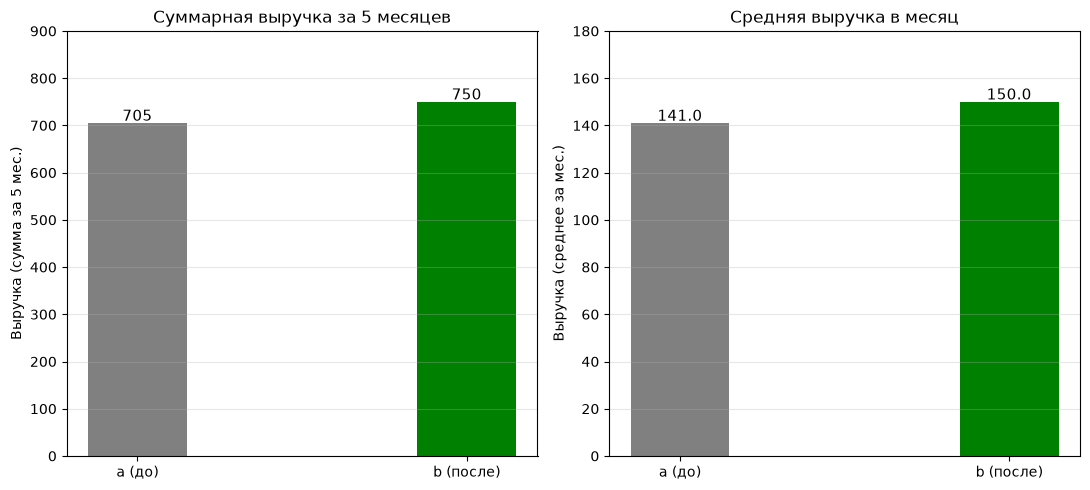

In [6]:
%matplotlib inline
total_a = a.sum()
total_b = b.sum()
mean_a = a.mean()
mean_b = b.mean()

print(f"Выручка до: {total_a}")
print(f"Выручка после: {total_b}")
print(f"Рост: {total_b - total_a}")
print()
print(f"Средняя выручка до: {mean_a:.2f}")
print(f"Средняя выручка после: {mean_b:.2f}")
print(f"Рост среднего: {mean_b - mean_a:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Суммарная выручка
bars = ax1.bar(["a (до)", "b (после)"], [total_a, total_b],
               color=["gray", "green"], width=0.3)
for bar, val in zip(bars, [total_a, total_b]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
             ha="center", fontsize=11)
ax1.set_ylabel("Выручка (сумма за 5 мес.)")
ax1.set_title("Суммарная выручка за 5 месяцев")
ax1.set_ylim(0, total_b * 1.2)
ax1.grid(axis="y", alpha=0.3)

# Средняя выручка
bars = ax2.bar(["a (до)", "b (после)"], [mean_a, mean_b],
               color=["gray", "green"], width=0.3)
for bar, val in zip(bars, [mean_a, mean_b]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}",
             ha="center", fontsize=11)
ax2.set_ylabel("Выручка (среднее за мес.)")
ax2.set_title("Средняя выручка в месяц")
ax2.set_ylim(0, mean_b * 1.2)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Вывод

Хи-квадрат: связь периода и дохода не значима (p >= 0.05).

Колмогоров–Смирнов: средняя прибыль после внедрения выше, но сдвиг статистически не значим (D = 0.400, p = 0.873).

Стьюдент (парный): t = 1.406, p = 0.233 при df = 4. Рост среднего дохода на 9 тыс. не значим на уровне 5%.

Все три критерия согласованы: направление эффекта положительное, но статистической значимости нет.

Ограничение: выборка из пяти наблюдений мала. Мощность недостаточна. Отсутствие значимости не доказывает отсутствие эффекта. Кроме того, t-критерий предполагает нормальность разностей, что при n = 5 проверить надёжно нельзя.